Моделирование мотивов в PWM. Эмпирическое распределение и p-value

In [1]:
pip install numpy matplotlib scipy biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 25.0 MB/s eta 0:00:00


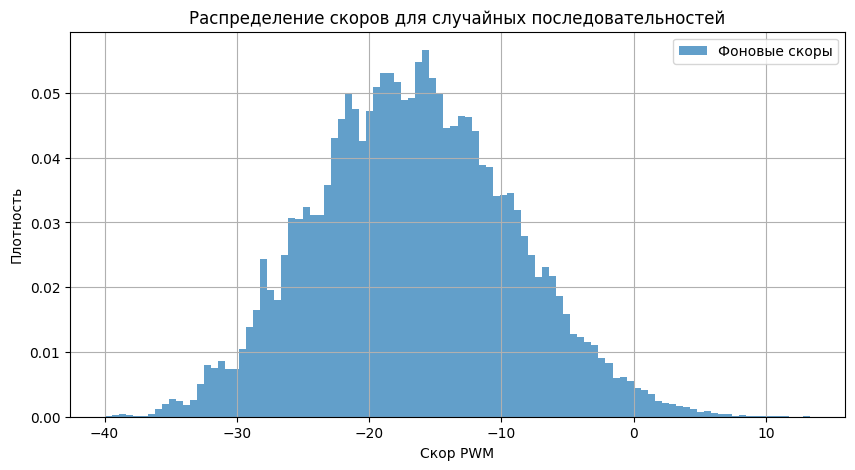

Порог для p-value ≈ 1e-4: 11.2281
Фактическое p-value для порога: 0.000100


In [16]:
import numpy as np
import matplotlib.pyplot as plt

pwm = np.array([[-1.47979496,  1.40062343, -1.47979496, -4.93922658, -4.93922658, -0.54690915,
                  1.21052054, -0.54690915, -1.47979496],
                [ 1.5166018 , -0.02181811, -0.95470391, -4.41413553, -4.41413553,  1.5166018,
                 -4.41413553, -4.41413553,  1.92571447],
                [-0.95470391, -4.41413553,  1.92571447,  2.24407595, -4.41413553, -4.41413553,
                  0.54006078,  1.92571447, -4.41413553],
                [-0.54690915, -4.93922658, -4.93922658, -4.93922658,  1.71898491, -0.54690915,
                 -4.93922658, -4.93922658, -1.47979496]])
L = 9
alphabet = ['A','C','G','T']
bg_probs = [0.295, 0.205, 0.205, 0.295]
nucl_to_idx = {n:i for i,n in enumerate(alphabet)}

# Генератор случайных последовательностей
def generate_random_seq(length=L, probs=bg_probs, rng=np.random.default_rng(42)):
    return ''.join(rng.choice(alphabet, size=length, p=probs))

# -Генерируем 100 000 фоновых последовательностей и считаем скоры
N = 100000
rng = np.random.default_rng(42)
scores = np.empty(N, dtype=float)

# Функция скора для последовательности
def score_seq(seq):
    total = 0.0
    for i, nuc in enumerate(seq):
        total += pwm[nucl_to_idx[nuc], i]
    return total

for i in range(N):
    seq = generate_random_seq(rng=rng)
    scores[i] = score_seq(seq)

# Гистограмма распределения скоров
plt.figure(figsize=(10,5))
plt.hist(scores, bins=100, density=True, alpha=0.7, label='Фоновые скоры')
plt.xlabel('Скор PWM')
plt.ylabel('Плотность')
plt.title('Распределение скоров для случайных последовательностей')
plt.legend()
plt.grid(True)
plt.savefig("score_distribution.png", dpi=150)
plt.show()

# Функция get_value(score)
def get_value(x):
    """Возвращает долю фоновых скоров >= x (эмпирическое p-value)"""
    return np.mean(scores >= x)

# p-value
target_pval = 1e-4
sorted_scores = np.sort(scores)[::-1]
k = int(np.ceil(target_pval * N))
threshold_emp = sorted_scores[k-1] if k>0 else sorted_scores[0]
print(f"Порог для p-value ≈ 1e-4: {threshold_emp:.4f}")
print(f"Фактическое p-value для порога: {get_value(threshold_emp):.6f}")